# Stochastic process

> **Definition 1.1 (Stochastic process).**  
> Let $T$ be an index set. A stochastic process with state space $(E,\mathcal E)$ is an indexed family $X=(X_t)_{t\in T}$, where each $ X_t:(\Omega,\mathcal F)\longrightarrow(E,\mathcal E) $ is a measurable random variable.

For a real-valued process, $E=\mathbb R$ and $\mathcal E=\mathcal B(\mathbb R)$. For an $\mathbb R^d$-valued process, each $X_t$ is a random vector. The definition contains two complementary viewpoints:

- If $t\in T$ is fixed, then $ \omega\longmapsto X_t(\omega)$ is a random variable. Its law $\mathcal L(X_t)$ is the marginal distribution of the process at time $t$.

- If $\omega\in\Omega$ is fixed, then $t\longmapsto X_t(\omega)$ is a sample path, trajectory, or realisation.

A process may also be identified pointwise with a two-variable map
$$
X:T\times\Omega\longrightarrow E,
\qquad
(t,\omega)\longmapsto X_t(\omega).
$$

The measurability of every coordinate $X_t$ does not automatically imply joint measurability of this two-variable map; joint measurability is an additional assumption when it is required.

## Classification by time and state space

The index set $T$ and the state space $E$ describe different aspects of a process.

| Time index | Typical notation | Example |
|---|---:|---|
| Discrete time | $T=\mathbb N_0$ or a finite grid | daily closing prices |
| Continuous time | $T=[0,\infty)$ | idealised continuously observed price |

| State space | Typical choice | Example |
|---|---:|---|
| Discrete state | $E = \mathbb Z$ or a finite set   | simple random walk |
| Continuous state | $E=\mathbb R^d$   | vector of asset returns |

A process can be discrete time and continuous state, continuous time and discrete state, or any other combination.

The phrase **continuous time process** refers only to the index set. It does not imply that the sample paths are continuous. Path continuity is a separate property.

## Finite-dimensional distributions

For times $t_1,\ldots,t_m\in T$, the random vector $(X_{t_1},\ldots,X_{t_m})$ has a joint law $\mathcal L(X_{t_1},\ldots,X_{t_m})$. The collection of these laws over all finite selections of times is called the collection of **finite-dimensional distributions** of the process. Marginal laws describe one time at a time; finite-dimensional laws also encode dependence across time.

This distinction will matter when we discuss stationarity and Gaussian processes.

## The canonical probability space

A process can be realised on many different probability spaces. The canonical construction removes unnecessary detail by taking the sample points themselves to be paths.

Let $T$ be an index set and let $(E,\mathcal E)$ be the state space. The path space is given by $\Omega =E^T = \{\omega:T\to E\}. $ A point $\omega\in\Omega$ is a complete path, and for each $t\in T$, the coordinate map $\pi_t(\omega)=\omega(t)$. The canonical $\sigma$-algebra is

$$ \mathcal F  = \sigma(\pi_t:t\in T), $$

the smallest $\sigma$-algebra that makes every coordinate map measurable.

A typical generator is a **cylinder set**

$$ C = \{\omega\in E^T: \omega(t_1)\in A_1,\ldots,\omega(t_m)\in A_m\}, $$

where $m<\infty$ and $A_j\in\mathcal E$. A cylinder event restricts finitely many coordinates and leaves all other times unrestricted.

Once a probability measure $\mathbb P$ is specified on this measurable space, $(\Omega,\mathcal F, \mathbb P)$ becomes a canonical probability space for the process. The coordinate family

$$ X_t(\omega)=\pi_t(\omega)=\omega(t), $$

is a stochastic process. The measure $\mathbb P$ determines its finite-dimensional distributions.

> **Remark.** If a process $X$ is originally defined on another probability space, its law on path space is the pushforward measure $\mathbb P_X=\mathbb P\circ X^{-1}$. On the canonical space, the process is the coordinate process and the probability measure carries the model.

## Filtrations, measurability, and adaptedness

To define a filtration, the index set $T$ must carry an order, typically $T = \mathbb N$ or $T = [0,\infty)$. 

> **Definition 3.1 (Filtration).**  
>A filtration is an increasing family $ (\mathcal F_t)_{t\in T} $ of sub-$\sigma $ algebras such that $ \mathcal F_s\subseteq\mathcal F_t $ whenever $ s\le t $.

The interpretation is that $\mathcal F_t$ contains the events whose occurrence can be determined using the information available by time $t$.

For a process $X$, its natural filtration is $\mathcal F_t^X = \sigma(X_s:s\le t)$. It contains precisely the information revealed by observing the process up to time $t$.

> **Definition 3.2 (Measurable function).**  
> A function $ Y:(\Omega,\mathcal F)\to(E,\mathcal E)$ is measurable if $Y^{-1}(A)=\{\omega:Y(\omega)\in A\}\in\mathcal F$ for every $A\in\mathcal E$.

For a real-valued random variable, it is enough to verify that

$$ \{Y\le x\}\in\mathcal F \qquad\text{for every }x\in\mathbb R. $$

> **Definition 3.3 (Adapted process).**  
> A process $ X=(X_t)_{t\in T} $ is adapted to $(\mathcal F_t)_{t\in T}$ if $X_t$ is $\mathcal F_t$ measurable for every $t$.

Adaptedness is a non-anticipation condition: the value observed at time $t$ must be determined by information available at time $t$, not by future information.

### Example: coin-toss increments and finite filtration

A finite experiment makes a filtration completely explicit. Consider three independent coin-toss increments

$$ \xi_1,\xi_2,\xi_3\in\{-1,+1\}. $$

The finite sample space is $\Omega_3=\{-1,+1\}^3.$

At time $n$, the information consists of the first $n$ coordinates. The atoms of $\mathcal F_n$ are therefore sets of paths sharing the same length $n$ prefix. Since every event in a finite $\sigma$-algebra is a union of atoms, this partition completely describes $\mathcal F_n$.

In a finite space, a random variable is $\mathcal F_n$-measurable exactly when it is constant on every atom of $\mathcal F_n$.

In [1]:
from itertools import product

OMEGA_3 = list(product((-1, 1), repeat=3))


def filtration_atoms(outcomes: list[tuple[int, ...]], n: int):
    """Partition outcomes according to the first n coordinates."""
    groups: dict[tuple[int, ...], list[tuple[int, ...]]] = {}
    for outcome in outcomes:
        groups.setdefault(outcome[:n], []).append(outcome)
    return list(groups.values())


def is_measurable_on_atoms(values, atoms) -> bool:
    """Finite-space measurability: values must be constant on each atom."""
    return all(len({values[outcome] for outcome in atom}) == 1 for atom in atoms)


for n in range(4):
    atoms = filtration_atoms(OMEGA_3, n)
    number_of_events = 2 ** len(atoms)
    print(
        f"F_{n}: {len(atoms)} atoms, "
        f"{number_of_events} events"
    )

S_2 = {outcome: sum(outcome[:2]) for outcome in OMEGA_3}
FUTURE_INCREMENT = {outcome: outcome[2] for outcome in OMEGA_3}

atoms_F2 = filtration_atoms(OMEGA_3, 2)

print("\nS_2 is F_2-measurable:",
      is_measurable_on_atoms(S_2, atoms_F2))
print("xi_3 is F_2-measurable:",
      is_measurable_on_atoms(FUTURE_INCREMENT, atoms_F2))

F_0: 1 atoms, 2 events
F_1: 2 atoms, 4 events
F_2: 4 atoms, 16 events
F_3: 8 atoms, 256 events

S_2 is F_2-measurable: True
xi_3 is F_2-measurable: False


The output illustrates the growth of information:

$$
\mathcal F_0\subseteq\mathcal F_1\subseteq\mathcal F_2\subseteq\mathcal F_3.
$$

The partial sum
$$
S_2=\xi_1+\xi_2
$$
is $\mathcal F_2$-measurable because it is determined by the first two tosses. The future increment $\xi_3$ is not $\mathcal F_2$-measurable because two paths with the same first two coordinates may have different third coordinates.

Thus, $S_n$ is adapted to the filtration generated by the increments, while the process $Y_n=\xi_{n+1}$ is not.

## Four key properties of stochastic processes

We now discuss a few foundational properties a stochastic process can have: sample paths, measurability, stationarity, and independent increments. These notions do not all have the same logical status. Every process has sample paths, and coordinate measurability is part of the definition of a process. Stationarity and independent increments, by contrast, are additional properties that some processes possess.

### Sample path

For fixed $\omega\in\Omega$, the function $t\longmapsto X_t(\omega)$ is a sample path. A plot of one simulated trajectory is therefore not the stochastic process itself. It is one outcome from the family of possible trajectories. Repeating the experiment produces different paths.

### Measurability

For each fixed $t$, the map

$$
X_t:(\Omega,\mathcal F)\to(E,\mathcal E)
$$

must be measurable. This guarantees that events such as

$$
\{X_t\le x\},
\qquad
\{X_t\in A\},
$$
belong to $\mathcal F$ and therefore have well-defined probabilities.

For an adapted process, this requirement is strengthened to $\{X_t\in A\}\in\mathcal F_t.$ The event must be decidable using information available by time $t$.

### Stationarity

> **Definition 4.1 (Strict stationarity).**  
> A process $X=(X_t)_{t\in T}$ is strictly stationary if, for every $m\ge1$, every $t_1,\ldots,t_m\in T$, and every admissible shift $h$,
> $$
> (X_{t_1},\ldots,X_{t_m}) \overset{d} = (X_{t_1+h},\ldots,X_{t_m+h}), $$

in which we have an equality in distribution. This specification is important, since an qquality without $\overset{d} =$ would imply random vectors are pointwise identical, which is generally a false statement.

Strict stationarity is a statement about all finite-dimensional distributions.

> **Definition 4.2 (Weak stationarity).**  
> A square integrable process is weakly stationary if $\mathbb E[X_t]=\mu$ is constant and $\text{Cov}(X_s,X_t)=\gamma(t-s)$ depends only on the lag, with $t, t + h \in T $.

Weak stationarity is also called second-order stationarity or covariance stationarity. (It is worth noting for correctness that for this definition to make sense, $X_t$ must have a finite second moment such that $mathbb E[\mid X_t \mid^2] < \infty$. Furthermore, strict stationarity does not by itself imply weak stationarity unless the required second moments exist. If a strictly stationary process has finite second moments, then it is weakly stationary.

Every i.i.d. sequence is strictly stationary.

### Independent increments

> **Definition 4.3 (Independent increments).**  
> A process \(X=(X_t)_{t\in T}\) has independent increments if, for every $ t_0<t_1<\cdots<t_m, $ the random variables
> $$
> X_{t_1}-X_{t_0},
> \ldots,
> X_{t_m}-X_{t_{m-1}}
> $$
> are independent.

This is stronger than zero covariance. Independence implies zero covariance when second moments exist, but zero covariance alone does not generally imply independence.

For a random walk $ S_n=\xi_1+\cdots+\xi_n, $ an increment over $[a,b]$ is
$$
S_b-S_a=\xi_{a+1}+\cdots+\xi_b
$$

for $0 \leq a < b $ and $ a,b \in \mathbb{N}_0 $.

Increments over disjoint intervals depend on disjoint collections of independent step variables and are therefore independent.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(12345)

n_paths = 100_000
n_steps = 20

# Independent ±1 increments
xi = rng.choice([-1, 1], size=(n_paths, n_steps))

# Random walk with S_0 = 0
S = np.column_stack([
    np.zeros(n_paths, dtype=int),
    np.cumsum(xi, axis=1)
])

# Disjoint increments
A = S[:, 10] - S[:, 0]       # interval (0, 10]
B = S[:, 20] - S[:, 10]      # interval (10, 20]

# Overlapping increment
C = S[:, 15] - S[:, 5]       # interval (5, 15]


def compare_joint_with_product(x, y, x_name, y_name):
    """
    Compare the empirical joint distribution of (x, y)
    with the product of their empirical marginal distributions.
    """
    x_values = np.sort(np.unique(x))
    y_values = np.sort(np.unique(y))

    # Empirical joint probability table
    joint_counts = pd.crosstab(
        pd.Series(x, name=x_name),
        pd.Series(y, name=y_name)
    )

    joint = joint_counts.reindex(
        index=x_values,
        columns=y_values,
        fill_value=0
    ) / len(x)

    # Empirical marginal distributions
    px = pd.Series(x).value_counts(normalize=True).reindex(
        x_values, fill_value=0
    )

    py = pd.Series(y).value_counts(normalize=True).reindex(
        y_values, fill_value=0
    )

    # Product of empirical marginals
    product = pd.DataFrame(
        np.outer(px.values, py.values),
        index=x_values,
        columns=y_values
    )

    difference = joint - product

    # Summary discrepancies
    max_abs_difference = np.abs(difference.to_numpy()).max()
    total_variation_distance = 0.5 * np.abs(
        difference.to_numpy()
    ).sum()

    print(f"{x_name} and {y_name}")
    print(f"Empirical correlation: {np.corrcoef(x, y)[0, 1]:.4f}")
    print(
        "Maximum absolute difference between "
        "joint and product probabilities: "
        f"{max_abs_difference:.5f}"
    )
    print(
        "Total variation distance: "
        f"{total_variation_distance:.5f}"
    )
    print()

    return joint, product, difference


joint_AB, product_AB, difference_AB = compare_joint_with_product(
    A, B, "A", "B"
)

joint_AC, product_AC, difference_AC = compare_joint_with_product(
    A, C, "A", "C"
)

A and B
Empirical correlation: -0.0057
Maximum absolute difference between joint and product probabilities: 0.00121
Total variation distance: 0.00766

A and C
Empirical correlation: 0.4942
Maximum absolute difference between joint and product probabilities: 0.01256
Total variation distance: 0.17962



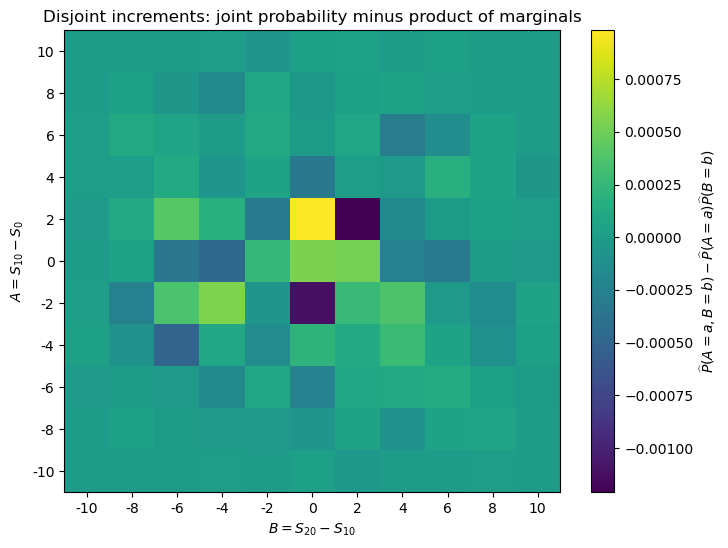

In [ ]:
# Plot the discrepancy matrices for disjoint increments
plt.figure(figsize=(8, 6))
plt.imshow(
    difference_AB,
    origin="lower",
    aspect="auto"
)
plt.colorbar(
    label=r"$\widehat{P}(A=a,B=b)"
          r"-\widehat{P}(A=a)\widehat{P}(B=b)$"
)
plt.xticks(
    range(len(difference_AB.columns)),
    difference_AB.columns
)
plt.yticks(
    range(len(difference_AB.index)),
    difference_AB.index
)
plt.xlabel(r"$B=S_{20}-S_{10}$")
plt.ylabel(r"$A=S_{10}-S_0$")
plt.title(
    "Disjoint increments: joint probability minus product of marginals"
)
plt.show()

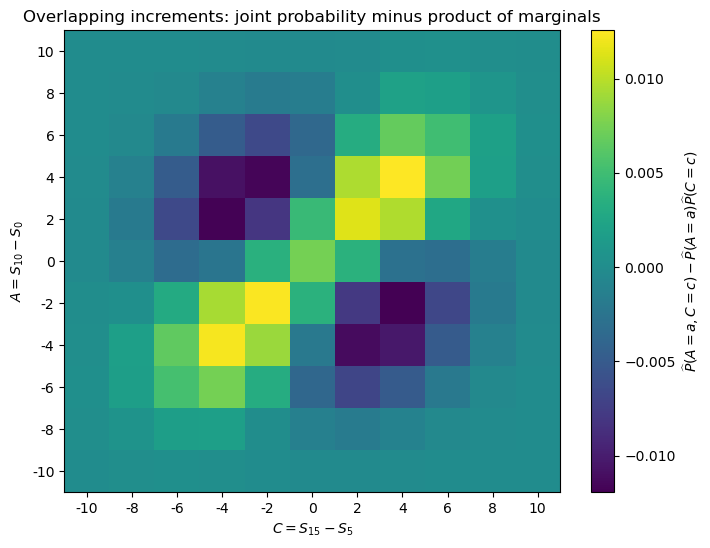

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(
    difference_AC,
    origin="lower",
    aspect="auto"
)
plt.colorbar(
    label=r"$\widehat{P}(A=a,C=c)"
          r"-\widehat{P}(A=a)\widehat{P}(C=c)$"
)
plt.xticks(
    range(len(difference_AC.columns)),
    difference_AC.columns
)
plt.yticks(
    range(len(difference_AC.index)),
    difference_AC.index
)
plt.xlabel(r"$C=S_{15}-S_5$")
plt.ylabel(r"$A=S_{10}-S_0$")
plt.title(
    "Overlapping increments: joint probability minus product of marginals"
)
plt.show()

Each heatmap shows the empirical joint probability minus the product of the empirical marginal probabilities, with each cell representing one possible pair of increment values. The purpose of this task is to ask: how far is the observed joint probability from what independence predicts?. For increments over disjoint intervals, the differences fluctuate close to zero, as predicted by independence. For overlapping intervals, a systematic pattern appears because the increments share some of the same random-walk steps.

Indeed, one see that the first heatmap is mostly close to zero. The small visible deviations, around $10^{−3}$, are Monte Carlo noise caused by using finitely many simulated paths. The second image is displays a systematic departure from factorisation.

## Stationary increments

A process has stationary increments if the law of $ \mathcal L (X_{t+h}-X_t) $ depends only on the lag $h$, not on the starting time $t$. For a discrete-time random walk,
$$
S_{n+m}-S_n
=
\xi_{n+1}+\cdots+\xi_{n+m},
$$
since the steps are identically distributed, this increment has the same law as
$$
S_m-S_0=S_m.
$$
Thus, a simple random walk has stationary increments.

This does not make the process stationary. Indeed, $\text{Var}(S_n)=n $ changes with $n$. The distinction stationary process $\neq$ process with stationary increments will be central when Brownian motion is introduced. The reason is because a stationary process looks statistically the same after shifting the entire time origin, while a process with stationary increments only requires changes over intervals of a given length to have the same distribution.

# Example: Simple symmetric random walk on a canonical space

We now construct a simple random walk without initially using a filtration. The space below is the canonical coordinate space for the increments. The cumulative-sum map sends each increment sequence to a random-walk path, and its pushforward measure is the corresponding law on random-walk path space.

Let $\Omega=\{-1,+1\}^{\mathbb N} $ and let $ \mathcal F = \mathcal P(\{-1,+1\})^{\otimes\mathbb N} $ be the product $\sigma$-algebra generated by cylinder sets. Let

$$
\mathbb P
=
\left(
\frac12\delta_{-1}
+
\frac12\delta_{+1}
\right)^{\otimes\mathbb N}.
$$

A point $\omega=(\omega_1,\omega_2,\ldots)$ is a complete sequence of possible steps. Define the coordinate variables $\xi_n(\omega)=\omega_n.$ Then the variables $(\xi_n)_{n\ge1}$ are independent and satisfy $ \mathbb P(\xi_n=1) = \mathbb P(\xi_n=-1) = \frac12. $

> **Definition 5.1 (Simple symmetric random walk).**  
> Define
> $$
> S_0=0,
> \qquad
> S_n=\sum_{k=1}^n\xi_k,
> \quad n\ge1.
> $$

The recursive form is
$$
S_{n+1}=S_n+\xi_{n+1}.
$$

The possible values at time $n$ are $-n,-n+2,\ldots,n-2,n.$ If $s$ has the same parity as $n$, reaching $S_n=s$ requires $u=\frac{n+s}{2}$ up-steps and $d=\frac{n-s}{2}$ down-steps. Hence

$$
\mathbb P(S_n=s) = \binom{n}{(n+s)/2}2^{-n}
$$

when $ \mid s \mid \leq n $ and $ n + s $ is even. If $ n+s $ is odd and $ \mid s \mid > n $, the probability is zero. If $n+s$ is odd, the probability is zero.

Because $\mathbb E[\xi_k]=0$ and $\text{Var}(\xi_k)=1$,
$$
\mathbb E[S_n]=0,
\qquad
\text{Var}(S_n)=n.
$$
The standard deviation therefore grows like $\sqrt n$.

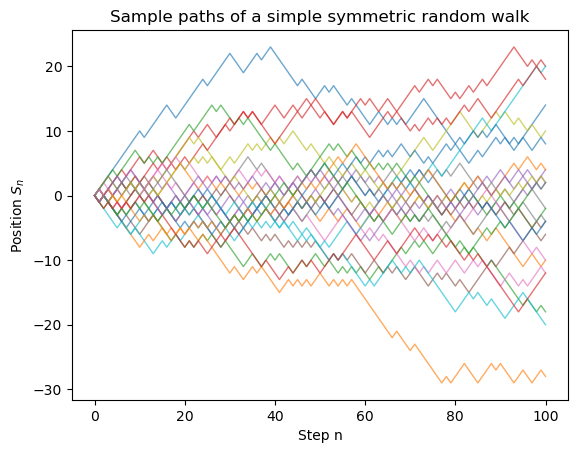

In [ ]:
def simulate_simple_random_walk(
    n_paths: int,
    n_steps: int,
    seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate simple symmetric random walks."""
    rng = np.random.default_rng(seed)
    steps = rng.choice((-1, 1), size=(n_paths, n_steps))
    walks = np.column_stack(
        [np.zeros(n_paths, dtype=int), np.cumsum(steps, axis=1)]
    )
    times = np.arange(n_steps + 1)
    return times, walks


times_rw, walks_rw = simulate_simple_random_walk(
    n_paths=25,
    n_steps=100,
    seed=SEED + 3,
)

for path in walks_rw:
    plt.plot(times_rw, path, linewidth=1.0, alpha=0.65)

plt.xlabel("Step n")
plt.ylabel(r"Position $S_n$")
plt.title("Sample paths of a simple symmetric random walk")
plt.show()

Each curve is one sample path $n\mapsto S_n(\omega)$. The process itself is the family $(S_n)_{n\ge0}$, not any one of the displayed paths.

When information becomes important, the natural filtration is $ \mathcal F_n^S = \sigma(S_0,\ldots,S_n). $ For the simple random walk this is also
$$
\mathcal F_n^S
=
\sigma(\xi_1,\ldots,\xi_n),
$$
because $\xi_n=S_n-S_{n-1}. $ In a separate entry, we will use this filtration when martingales are introduced.